## Diffusion Models : Intuition and a Minimal Implementation

Diffusion models generate data by **gradually destroying structure with noise and then learning how to reverse that process step by step**.

In this notebook, we build a **minimal diffusion pipeline** from scratch to show how forward noising and reverse denoising actually work in practice. Instead of focusing on state-of-the-art results, the goal is **clarity and intuition**.

We start by adding controlled Gaussian noise to real data until it becomes nearly pure noise. A neural network is then trained to **predict and remove this noise**, allowing us to reconstruct structured samples from randomness.

This notebook is intended for readers who:

* want an intuitive understanding of diffusion models,
* prefer simple, readable implementations,
* and want to see how theory maps to working code.

By the end, you will see how forward diffusion, reverse diffusion, and a U-Net backbone fit together to generate new samples.

## Diffusion Models: Intuition (No Math)

Diffusion models work by breaking a difficult generation problem into many small, manageable steps.

Instead of generating data in one shot, we **gradually add noise** to real samples until all structure is destroyed. This process is simple, fixed, and fully controlled.

The key idea is to then **learn how to reverse this corruption one step at a time**. Because the forward noising process is known, a model can be trained to predict how to remove a small amount of noise at each step.

In practice, the model does not recover the original data directly. It learns a conditional rule:
[
p(x_{t-1} \mid x_t)
]
which tells it how to move from a noisy sample toward a slightly cleaner one.

By repeatedly applying this learned denoising step, random noise is gradually transformed into structured data.

This step-by-step reversal is what allows diffusion models to generate high-quality samples, even though diffusion is irreversible in the physical world.

In [1]:
import os
import gc
import math
import json
import glob
import shutil
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import imagehash
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    optimizers,
    utils,
    callbacks,
    metrics,
    losses,
    activations,
)

2026-01-11 10:29:15.077773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768127355.256402      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768127355.304960      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Configuration Parameters
Set key hyperparameters for image size, batch size, embedding dimensions, and training settings.

In [2]:
# Parameter
IMAGE_SIZE = 64
BATCH_SIZE = 32  # Reduced to allow larger model/better gradients
DATASET_REPETITIONS = 5
LOAD_MODEL = False

NOISE_EMBEDDING_SIZE = 64  # Increased for richer conditioning
PLOT_DIFFUSION_STEPS = 100  # CRITICAL: increased for quality generation

# optimization
EMA = 0.999
LEARNING_RATE = 5e-4  # Reduced for finer detail learning
WEIGHT_DECAY = 1e-5  # Reduced to allow more model capacity
EPOCHS = 100  # Increased - diffusion models need more training

### Dataset Preprocessing
Load flower dataset, clean images (remove blurry/duplicate), resize to 64x64, and extract class labels from folder structure.

In [3]:
dataset_root = "/kaggle/input/pytorch-challange-flower-dataset/dataset"
train_folder = os.path.join(dataset_root, "train")
test_folder = os.path.join(dataset_root, "test")
valid_folder = os.path.join(dataset_root, "valid")
cat_to_name_path = os.path.join(dataset_root, "cat_to_name.json")
output_folder = "/kaggle/working/clean"
labels_file = "/kaggle/working/image_labels.npy"  # We'll create class mapping
target_size = (64, 64)
blur_threshold = 2.0
duplicate_threshold = 1
NUM_CLASSES = 102

os.makedirs(output_folder, exist_ok=True)

# Load category to name mapping if available
if os.path.exists(cat_to_name_path):
    with open(cat_to_name_path, 'r') as f:
        cat_to_name = json.load(f)
    print(f"Loaded {len(cat_to_name)} flower categories")
else:
    print("Warning: cat_to_name.json not found, will use folder-based labels")
    cat_to_name = None

# Find all image files recursively and extract labels from folder structure
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
all_image_data = []  # (path, class_id)

print("Scanning for images and extracting labels...")
for folder_name, folder_path in [("train", train_folder), ("test", test_folder), ("valid", valid_folder)]:
    if not os.path.exists(folder_path):
        print(f"  {folder_name}: folder not found, skipping")
        continue
    
    count_before = len(all_image_data)
    
    # Each subfolder represents a class
    for class_folder in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_folder)
        if not os.path.isdir(class_path):
            continue
        
        # Extract class ID from folder name (e.g., "1", "10", "102")
        try:
            class_id = int(class_folder) - 1  # Convert 1-102 to 0-101
        except ValueError:
            print(f"Warning: Skipping non-numeric folder {class_folder}")
            continue
        
        # Find all images in this class folder
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(image_extensions):
                img_path = os.path.join(class_path, img_file)
                all_image_data.append((img_path, class_id))
    
    print(f"  {folder_name}: found {len(all_image_data) - count_before} images")

print(f"\nTotal: {len(all_image_data)} images across {NUM_CLASSES} classes")

if len(all_image_data) == 0:
    raise ValueError("No image files to process")

# Preprocessing with label preservation
hashes = {}
skipped_counts = {"corrupted": 0, "blurry": 0, "duplicate": 0, "errors": 0}
saved_data = []  # (output_filename, class_id)

for img_path, class_id in tqdm(all_image_data, desc="Processing images"):
    # Check valid image
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        skipped_counts["corrupted"] += 1
        continue
    
    # Check blur
    try:
        gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
        fm = cv2.Laplacian(gray, cv2.CV_64F).var()
        if fm < blur_threshold:
            skipped_counts["blurry"] += 1
            continue
    except Exception:
        skipped_counts["errors"] += 1
        continue
    
    # Resize
    try:
        img_resized = img.resize(target_size, Image.LANCZOS)
    except Exception:
        skipped_counts["errors"] += 1
        continue
    
    # Check duplicates
    try:
        img_hash = imagehash.phash(img_resized)
        duplicate_found = False
        for h in hashes.values():
            if abs(img_hash - h) < duplicate_threshold:
                duplicate_found = True
                break
        if duplicate_found:
            skipped_counts["duplicate"] += 1
            continue
    except Exception:
        skipped_counts["errors"] += 1
        continue
    
    # Save cleaned image with unique name
    try:
        output_filename = f"img_{len(saved_data):06d}.jpg"
        output_path = os.path.join(output_folder, output_filename)
        img_resized.save(output_path, format='JPEG', quality=95)
        hashes[output_filename] = img_hash
        saved_data.append((output_filename, class_id))
    except Exception as e:
        print(f"Error saving image: {e}")
        skipped_counts["errors"] += 1
        continue

# Save label mapping
labels_array = np.array([class_id for _, class_id in saved_data], dtype=np.int32)
np.save(labels_file, labels_array)

print(f"\n✓ Cleaning complete! {len(saved_data)} images saved to {output_folder}")
print(f"✓ Labels saved to {labels_file}")
print(f"✗ Skipped - Corrupted: {skipped_counts['corrupted']}, Blurry: {skipped_counts['blurry']}, "
      f"Duplicates: {skipped_counts['duplicate']}, Errors: {skipped_counts['errors']}")
print(f"\nTotal processed: {len(all_image_data)}")
print(f"Success rate: {100 * len(saved_data) / len(all_image_data):.1f}%")

# Show class distribution
unique, counts = np.unique(labels_array, return_counts=True)
print(f"\nClass distribution: {len(unique)} classes, "
      f"min={counts.min()} imgs, max={counts.max()} imgs, avg={counts.mean():.1f} imgs/class")

Scanning for images and extracting labels...
  train: found 6552 images
  test: found 0 images
  valid: found 818 images

Total: 7370 images across 102 classes


Processing images: 100%|██████████| 7370/7370 [03:30<00:00, 34.98it/s]


✓ Cleaning complete! 7359 images saved to /kaggle/working/clean
✓ Labels saved to /kaggle/working/image_labels.npy
✗ Skipped - Corrupted: 0, Blurry: 1, Duplicates: 10, Errors: 0

Total processed: 7370
Success rate: 99.9%

Class distribution: 102 classes, min=34 imgs, max=234 imgs, avg=72.1 imgs/class


### Load Dataset with Labels
Create TensorFlow dataset from cleaned images and attach corresponding class labaels.

In [4]:
# Load data WITH labels
labels = np.load("/kaggle/working/image_labels.npy")
print(f"Loaded {len(labels)} labels, range: {labels.min()}-{labels.max()}")

# Create dataset from images
train_data = utils.image_dataset_from_directory(
    "/kaggle/working/clean",
    labels=None, 
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=None,
    shuffle=False,  
    seed=42,
    interpolation="bilinear",
)

# Convert labels to TensorFlow constant for efficient lookup
labels_tensor = tf.constant(labels, dtype=tf.int32)

# Create a dataset that returns (image, label) pairs using tf.gather
indexed_data = train_data.enumerate()
labeled_data = indexed_data.map(
    lambda idx, img: (img, tf.gather(labels_tensor, idx))
)

Loaded 7359 labels, range: 0-101
Found 7359 files.


I0000 00:00:1768127584.896726      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
unique, counts = np.unique(labels, return_counts=True)
print("Num classes:", len(unique))
print("Classes:", unique)

Num classes: 102
Classes: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101]


### Create Training Pipeline
Normalize images to [0, 1] range, batch the data, and optimize with prefetching.

In [6]:
# Preprocess
def preprocess(img):
    # Cast to float32 and normalize to [0, 1] range
    img = tf.cast(img, "float32")
    # Avoid division by zero by adding epsilon
    img = img / 255.0
    # Clip values to ensure they're in valid range
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img

In [7]:
# Use labeled_data for conditional training
train = (
    labeled_data
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

In [8]:
def sample_batch(dataset):
    try:
        batch = dataset.take(1).get_single_element()
        if isinstance(batch, tuple):
            batch = batch[0]
        return batch.numpy()
    except Exception as e:
        print(f"Error sampling batch: {e}")
        return None

In [9]:
train_sample = sample_batch(train)
display(train_sample)

array([[[[0.05098039, 0.08627451, 0.01176471],
         [0.02745098, 0.0627451 , 0.        ],
         [0.0627451 , 0.10588235, 0.05098039],
         ...,
         [0.7058824 , 0.6509804 , 0.6509804 ],
         [0.6862745 , 0.60784316, 0.6509804 ],
         [0.6901961 , 0.60784316, 0.6666667 ]],

        [[0.07450981, 0.11372549, 0.        ],
         [0.02352941, 0.05882353, 0.        ],
         [0.09411765, 0.13333334, 0.03921569],
         ...,
         [0.70980394, 0.654902  , 0.654902  ],
         [0.69411767, 0.63529414, 0.654902  ],
         [0.57254905, 0.5137255 , 0.5411765 ]],

        [[0.10588235, 0.14509805, 0.        ],
         [0.1882353 , 0.22352941, 0.00784314],
         [0.12941177, 0.16470589, 0.        ],
         ...,
         [0.67058825, 0.6313726 , 0.62352943],
         [0.6627451 , 0.63529414, 0.6039216 ],
         [0.29803923, 0.28235295, 0.23921569]],

        ...,

        [[0.01176471, 0.05882353, 0.        ],
         [0.01960784, 0.07450981, 0.        ]

### Diffusion Noise Schedules
Define how noise is added over time. Three variants: linear, cosine, and offset cosine schedules.

In [10]:
# Diffusion Schedules -> Linear
# To make sure in early stages noising process, we take smaller steps than in later ones
def linear_diffusion_schedule(diffusion_times):
    min_rate = 0.0001
    max_rate = 0.02
    betas = min_rate + diffusion_times * (max_rate - min_rate)
    alphas = 1 - betas
    alpha_bar = tf.math.cumprod(alphas)
    signal_rates = tf.sqrt(alpha_bar)  # Fixed: was 1-alpha_bar
    noise_rates = tf.sqrt(1 - alpha_bar)
    return noise_rates, signal_rates

In [11]:
def cosine_diffusion_schedulers(diffusion_times):
    signal_rates= tf.cos(diffusion_times * math.pi/2)
    noise_rates= tf.sin(diffusion_times * math.pi/2)
    return noise_rates, signal_rates

In [12]:
def offset_cosine_diffusion_schedulers(diffusion_times):
    min_signal_rate= 0.02
    max_signal_rate= 0.95
    start_angle= tf.acos(max_signal_rate)
    end_angle= tf.acos(min_signal_rate)

    diffusion_angle= start_angle+diffusion_times * (end_angle- start_angle)
    signal_rate= tf.cos(diffusion_angle)
    noise_rate= tf.sin(diffusion_angle)

    return noise_rate, signal_rate

In [13]:
T = 1000
diffusion_times= tf.convert_to_tensor([x/T for x in range(T)])
linear_nr, linear_sr= linear_diffusion_schedule(diffusion_times)
cosine_nr, cosine_sr= cosine_diffusion_schedulers(diffusion_times)
offset_cosine_nr, offset_cosine_sr = offset_cosine_diffusion_schedulers(diffusion_times)

### Visualize Noise Schedules
Compare signal preservation curves across different schedule types.

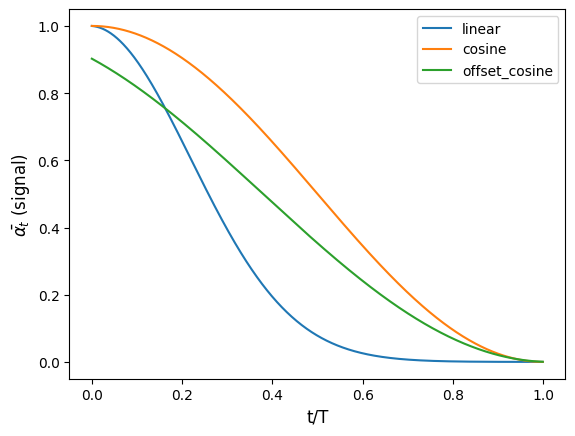

In [14]:
plt.plot(
    diffusion_times, linear_sr**2, linewidth=1.5, label="linear"
)
plt.plot(
    diffusion_times, cosine_sr**2, linewidth=1.5, label="cosine"
)
plt.plot(
    diffusion_times,
    offset_cosine_sr**2,
    linewidth=1.5,
    label="offset_cosine",
)

plt.xlabel("t/T", fontsize=12)
plt.ylabel(r"$\bar{\alpha_t}$ (signal)", fontsize=12)
plt.legend()
plt.show()

### Sinusoidal Time Embedding
Encode diffusion timesteps using sinusoidal positional embeddings for the model to understand noise levels.

In [15]:
@tf.keras.utils.register_keras_serializable()
class SinusoidalEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim

    def call(self, x):
        # x can be scalar () or batched (B,)
        # Ensure we have shape (B,)
        if len(x.shape) == 0:
            x = tf.expand_dims(x, 0)
        elif len(x.shape) > 1:
            x = tf.squeeze(x)
        
        half_dim = self.dim // 2
        emb_scale = tf.math.log(10000.0) / (half_dim - 1)
        emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -emb_scale)
        emb = x[:, None] * emb[None, :]
        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)

        return emb  # (B, dim)

    def get_config(self):
        return {"dim": self.dim}

### Visualize Time Embeddings
Display how timesteps are encoded across embedding dimensions.

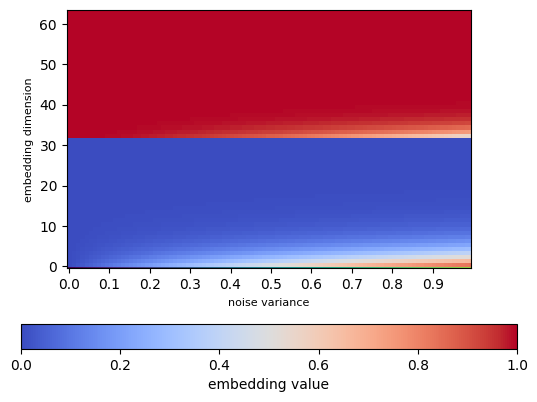

In [16]:
# Create a simple embedding layer instance for visualization
temp_embedding = SinusoidalEmbedding(NOISE_EMBEDDING_SIZE)

embedding_list = []
for y in np.arange(0, 1, 0.01):
    emb = temp_embedding(tf.constant([y], dtype=tf.float32))
    embedding_list.append(emb.numpy()[0])

embedding_array = np.array(np.transpose(embedding_list))
fig, ax = plt.subplots()
ax.set_xticks(
    np.arange(0, 100, 10), labels=np.round(np.arange(0.0, 1.0, 0.1), 1)
)
ax.set_ylabel("embedding dimension", fontsize=8)
ax.set_xlabel("noise variance", fontsize=8)
plt.pcolor(embedding_array, cmap="coolwarm")
plt.colorbar(orientation="horizontal", label="embedding value")
ax.imshow(embedding_array, interpolation="nearest", origin="lower")
plt.show()

### Class Conditioning Layer
Create embedding layer to encode flower class labels for conditional generation.

In [50]:
# Class embedding for conditioning
class_embedding_layer = layers.Embedding(
    input_dim=NUM_CLASSES,  # 102 classes
    output_dim=128,  # Same dim as noise embedding
    name="class_embedding"
)

### Analyze Class Distribution
Check how training data is distributed across the 102 flower classes.

Class Distribution Analysis:
Total classes: 102
Total images: 7359
Min images per class: 34
Max images per class: 234
Mean images per class: 72.1
Median images per class: 58.5

Class      Count      %         
------------------------------
0          35         0.48%
10         78         1.06%
25         36         0.49%
50         234        3.18%
75         103        1.40%
101        42         0.57%


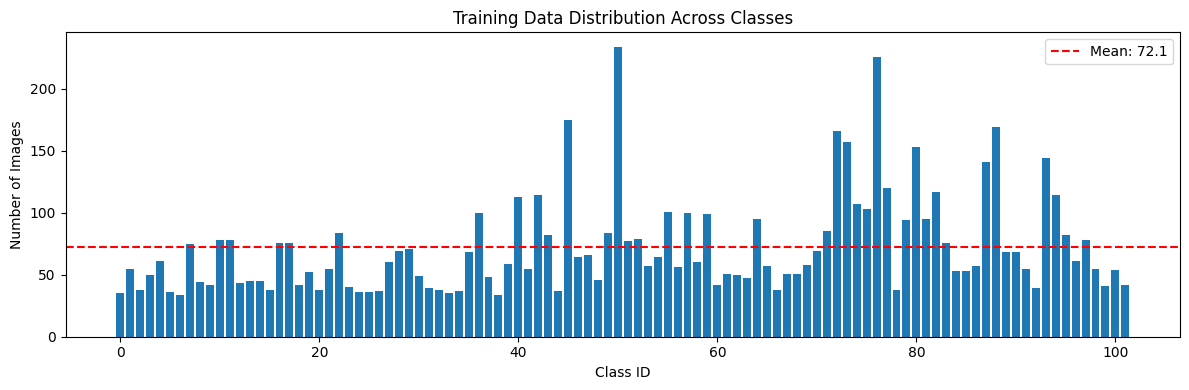

In [51]:
# Check class distribution in training data
labels = np.load("/kaggle/working/image_labels.npy")
unique, counts = np.unique(labels, return_counts=True)

print("Class Distribution Analysis:")
print("="*60)
print(f"Total classes: {len(unique)}")
print(f"Total images: {len(labels)}")
print(f"Min images per class: {counts.min()}")
print(f"Max images per class: {counts.max()}")
print(f"Mean images per class: {counts.mean():.1f}")
print(f"Median images per class: {np.median(counts):.1f}")

# Check specific classes we tested
test_classes = [0, 10, 25, 50, 75, 101]
print(f"\n{'Class':<10} {'Count':<10} {'%':<10}")
print("-"*30)
for cls in test_classes:
    if cls in unique:
        idx = np.where(unique == cls)[0][0]
        count = counts[idx]
        percentage = (count / len(labels)) * 100
        print(f"{cls:<10} {count:<10} {percentage:.2f}%")
    else:
        print(f"{cls:<10} {'MISSING':<10} {'0.00%':<10}")

# Plot distribution
plt.figure(figsize=(12, 4))
plt.bar(unique, counts)
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.title('Training Data Distribution Across Classes')
plt.axhline(y=counts.mean(), color='r', linestyle='--', label=f'Mean: {counts.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

### UNet Building Blocks
Define residual blocks, downsampling, and upsampling layers for the denoising network.

In [18]:
def Residual_block(width):
    def apply(x):
        input_width = x.shape[3]
        if input_width == width:
            residual = x
        else:
            residual = layers.Conv2D(width, kernel_size=1)(x)
        x = layers.BatchNormalization(center=False, scale=False)(x)
        x = layers.Conv2D(
            width, kernel_size=3, padding="same", activation=activations.swish
        )(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same")(x)
        x = layers.Add()([x, residual])
        return x

    return apply

In [19]:
def Down_block(width, block_depth):
    def apply(x):
        x, skips=x
        for _ in range(block_depth):
            x=Residual_block(width)(x)
            skips.append(x)
        x=layers.AveragePooling2D(pool_size=2)(x)
        return x
    return apply

In [20]:
def Up_block(width, block_depth):
    def apply(x):
        x,skips=x
        x=layers.UpSampling2D(size=2, interpolation="bilinear")(x)
        for _ in range(block_depth):
            x = layers.Concatenate()([x, skips.pop()])
            x=Residual_block(width)(x)
        return x
    return apply

### Build UNet Architecture
Construct the denoising network with class and time conditioning, using encoder-decoder structure with skip connections.

In [21]:
# Custom layer for spatial tiling
@tf.keras.utils.register_keras_serializable()
class SpatialTile(layers.Layer):
    def __init__(self, target_size, **kwargs):
        super().__init__(**kwargs)
        self.target_size = target_size
    
    def call(self, x):
        # x shape: (batch, 1, 1, channels)
        # output shape: (batch, target_size, target_size, channels)
        return tf.tile(x, [1, self.target_size, self.target_size, 1])
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.target_size, self.target_size, input_shape[-1])
    
    def get_config(self):
        config = super().get_config()
        config.update({"target_size": self.target_size})
        return config

# ===== Class embedding =====
class_embedding_layer = layers.Embedding(
    input_dim=NUM_CLASSES,
    output_dim=NOISE_EMBEDDING_SIZE,
    name="class_embedding"
)

# ===== Inputs =====
noisy_images = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="noisy_images"
)
noise_variances = layers.Input(
    shape=(), name="noise_variances"
)
class_labels = layers.Input(
    shape=(), dtype=tf.int32, name="class_labels"
)

# ===== Initial conv =====
x = layers.Conv2D(64, kernel_size=1)(noisy_images)  # Increased from 32

# ===== Noise embedding =====
# Create embedding: (batch,) -> (batch, embedding_dim)
noise_emb = SinusoidalEmbedding(NOISE_EMBEDDING_SIZE)(noise_variances)
# Reshape and tile to match spatial dimensions
noise_emb = layers.Reshape((1, 1, NOISE_EMBEDDING_SIZE))(noise_emb)
noise_emb = SpatialTile(IMAGE_SIZE)(noise_emb)

# ===== Class embedding =====
# (batch,) -> (batch, embedding_dim)
class_emb = class_embedding_layer(class_labels)
# Reshape and tile to match spatial dimensions
class_emb = layers.Reshape((1, 1, NOISE_EMBEDDING_SIZE))(class_emb)
class_emb = SpatialTile(IMAGE_SIZE)(class_emb)

# ===== Combine =====
x = layers.Concatenate()([x, noise_emb, class_emb])

# ===== UNet (increased capacity) =====
skips = []

x = Down_block(64, 2)([x, skips])   # Increased from 32
x = Down_block(128, 2)([x, skips])  # Increased from 64
x = Down_block(256, 2)([x, skips])  # Increased from 96

x = Residual_block(256)(x)  # Increased from 128
x = Residual_block(256)(x)

x = Up_block(256, 2)([x, skips])  # Increased from 96
x = Up_block(128, 2)([x, skips])  # Increased from 64
x = Up_block(64, 2)([x, skips])   # Increased from 32

outputs = layers.Conv2D(3, 1, kernel_initializer="zeros")(x)

unet = models.Model(
    [noisy_images, noise_variances, class_labels],
    outputs,
    name="unet"
)

In [22]:
unet.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise_variances     │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_labels        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinusoidal_embeddi… │ (None, 64)        │          0 │ noise_variances[… │
│ (SinusoidalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_embedding     │ (None, 64)        │      6,528 │ class_labels[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy_images        │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ sinusoidal_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ class_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        256 │ noisy_images[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_tile        │ (None, 64, 64,    │          0 │ reshape[0][0]     │
│ (SpatialTile)       │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_tile_1      │ (None, 64, 64,    │          0 │ reshape_1[0][0]   │
│ (SpatialTile)       │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 192)              │            │ spatial_tile[0][… │
│                     │                   │            │ spatial_tile_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        384 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    110,656 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     12,352 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ add[0][0]         │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 10,427,523 (39.78 MB)

 Trainable params: 10,420,867 (39.75 MB)

 Non-trainable params: 6,656 (26.00 KB)

In [23]:
# Debug: Check input layer names
print("UNet input layers:")
for i, inp in enumerate(unet.inputs):
    print(f"  Input {i}: name='{inp.name}', shape={inp.shape}")

UNet input layers:
  Input 0: name='noisy_images', shape=(None, 64, 64, 3)
  Input 1: name='noise_variances', shape=(None,)
  Input 2: name='class_labels', shape=(None,)


### Diffusion Model Class
Main model implementing training loop, denoising, and reverse diffusion for image generation.

In [24]:
class Diffusion_model(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.network = unet
        self.normalizer = layers.Normalization()
        self.diffusion_schedule = offset_cosine_diffusion_schedulers

        # ===== EMA NETWORK (clone) =====
        self.ema_network = tf.keras.models.clone_model(unet)
        self.ema_network.set_weights(self.network.get_weights())

        self.noise_loss_tracker = metrics.Mean(name="noise_loss")

    @property
    def metrics(self):
        return [self.noise_loss_tracker]

    # ===== DENOISE =====
    def denoise(self, noisy_img, noise_rate, signal_rate, labels, training):
        net = self.network if training else self.ema_network
        # Squeeze to get scalar noise_variance for each batch element
        noise_variance = tf.squeeze(noise_rate ** 2)
        pred_noise = net([noisy_img, noise_variance, labels], training=training)
        pred_img = (noisy_img - noise_rate * pred_noise) / signal_rate
        return pred_noise, pred_img

    # ===== TRAIN STEP =====
    def train_step(self, data):
        images, labels = data
        images = self.normalizer(images, training=True)
        labels = tf.cast(labels, tf.int32)

        batch_size = tf.shape(images)[0]
        noise = tf.random.normal(tf.shape(images))
        # Generate scalar diffusion times for each batch element
        diffusion_time = tf.random.uniform((batch_size,), 0.0, 1.0)

        # Expand dims for broadcasting
        diffusion_time_expanded = diffusion_time[:, None, None, None]
        noise_rate, signal_rate = self.diffusion_schedule(diffusion_time_expanded)
        noisy_images = signal_rate * images + noise_rate * noise

        with tf.GradientTape() as tape:
            # Pass scalar diffusion_time to network
            pred_noise = self.network(
                [noisy_images, diffusion_time, labels], training=True
            )
            loss = self.compiled_loss(noise, pred_noise)

        grads = tape.gradient(loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(
            zip(grads, self.network.trainable_weights)
        )

        # EMA update
        for w, ew in zip(self.network.weights, self.ema_network.weights):
            ew.assign(EMA * ew + (1.0 - EMA) * w)

        self.noise_loss_tracker.update_state(loss)
        return {"noise_loss": self.noise_loss_tracker.result()}

    # ===== GENERATION (Simple Denoising) =====
    def reverse_diffusion(self, initial_noise, labels, steps):
        img = initial_noise
        step_size = 1.0 / steps

        for step in range(steps):
            # Current diffusion time
            t_scalar = 1.0 - step * step_size
            t_batch = tf.ones((tf.shape(img)[0],)) * t_scalar
            
            # Get current noise and signal rates
            t_expanded = t_batch[:, None, None, None]
            noise_rate, signal_rate = self.diffusion_schedule(t_expanded)
            
            # Predict noise and clean image
            pred_noise, pred_img = self.denoise(
                img, noise_rate, signal_rate, labels, training=False
            )

            # Get next step rates
            next_t = tf.maximum(t_expanded - step_size, 0.0)
            next_noise_rate, next_signal_rate = self.diffusion_schedule(next_t)
            
            # Simple deterministic update
            img = next_signal_rate * pred_img + next_noise_rate * pred_noise

        return pred_img

    def generate(self, num_images, diffusion_steps, class_labels=None, initial_noise=None):
        if class_labels is None:
            class_labels = tf.random.uniform(
                (num_images,), 0, NUM_CLASSES, dtype=tf.int32
            )

        if initial_noise is None:
            initial_noise = tf.random.normal(
                (num_images, IMAGE_SIZE, IMAGE_SIZE, 3)
            )
        
        images = self.reverse_diffusion(initial_noise, class_labels, diffusion_steps)
        return tf.clip_by_value(images, 0.0, 1.0)

### Initialize Model
Create diffusion model instance and adapt the normalizer to training data statistics.

In [25]:
ddm= Diffusion_model()
# Adapt normalizer on images only (not labels)
ddm.normalizer.adapt(train.map(lambda img, label: img))

In [26]:
if LOAD_MODEL:
    ddm.built=True
    ddm.load_weights()

### Compile Model
Configure optimizer (AdamW) and loss function (MAE) for training.

In [27]:
ddm.compile(
    optimizer=optimizers.AdamW(
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    ),
    loss=losses.MeanAbsoluteError(),
)

### Setup Training Callbacks
Configure model checkpointing and image generation during training.

In [28]:
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoints/checkpoint.weights.h5",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

In [29]:
class ImageGenerator(tf.keras.callbacks.Callback):
    def __init__(self, num_img, save_dir="./output"):
        super().__init__()
        self.num_img = num_img
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        class_labels = tf.random.uniform(
            shape=(self.num_img,),
            minval=0,
            maxval=NUM_CLASSES,
            dtype=tf.int32,
        )

        generated_images = self.model.generate(
            num_images=self.num_img,
            diffusion_steps=PLOT_DIFFUSION_STEPS,
            class_labels=class_labels,
        ).numpy()

        for i, img in enumerate(generated_images):
            plt.imshow((img * 255).astype("uint8"))
            plt.axis("off")
            path = os.path.join(
                self.save_dir, f"epoch_{epoch:03d}_img_{i:02d}.png"
            )
            plt.savefig(path, bbox_inches="tight", pad_inches=0)
            plt.close()

        print(f"[Epoch {epoch}] Saved {self.num_img} samples")

In [30]:
ddm.build([
    (None, IMAGE_SIZE, IMAGE_SIZE, 3),
    (None, 1, 1, 1),
    (None,)
])

### Train the Model
Run training for 100 epochs with checkpointing and sample generation.

In [31]:
image_generator_callback = ImageGenerator(num_img=10)

his = ddm.fit(
    train,
    epochs=100,
    callbacks=[
        model_checkpoint_callback,
        image_generator_callback,
    ],
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:667: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
I0000 00:00:1768127602.287933     117 service.cc:148] XLA service 0x7915380cc6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768127602.288693     117 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768127604.089255     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/229 ━━━━━━━━━━━━━━━━━━━━ 1:55:22 30s/step - noise_loss: 0.7983

I0000 00:00:1768127620.223008     117 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - noise_loss: 0.3700[Epoch 0] Saved 10 samples
229/229 ━━━━━━━━━━━━━━━━━━━━ 69s 171ms/step - noise_loss: 0.3696
Epoch 2/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - noise_loss: 0.2067[Epoch 1] Saved 10 samples
229/229 ━━━━━━━━━━━━━━━━━━━━ 37s 162ms/step - noise_loss: 0.2067
Epoch 3/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - noise_loss: 0.1952[Epoch 2] Saved 10 samples
229/229 ━━━━━━━━━━━━━━━━━━━━ 37s 162ms/step - noise_loss: 0.1952
Epoch 4/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - noise_loss: 0.1900[Epoch 3] Saved 10 samples
229/229 ━━━━━━━━━━━━━━━━━━━━ 37s 162ms/step - noise_loss: 0.1900
Epoch 5/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - noise_loss: 0.1872[Epoch 4] Saved 10 samples
229/229 ━━━━━━━━━━━━━━━━━━━━ 37s 162ms/step - noise_loss: 0.1872
Epoch 6/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - noise_loss: 0.1851[Epoch 5] Saved 10 samples
229/229 ━━━━━━━━━━━━━━━━━━━━ 37s 162ms/step - noise_loss: 0.1851
Epoch 7/10

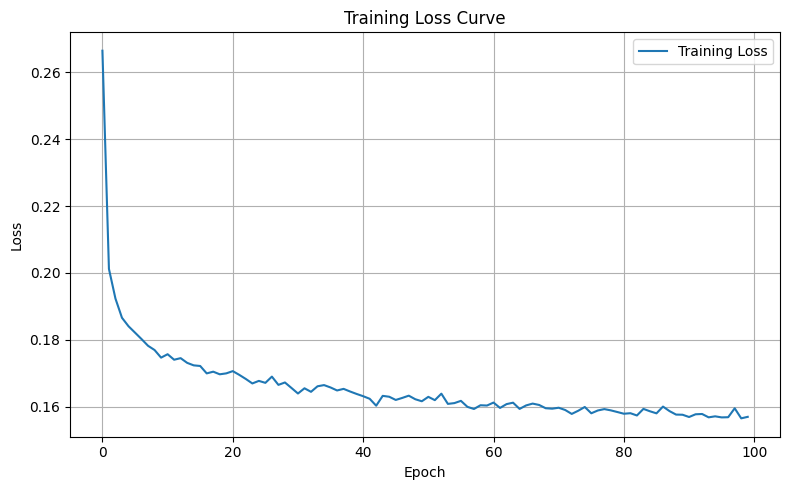

In [37]:
import matplotlib.pyplot as plt

history = his.history

plt.figure(figsize=(8,5))
plt.plot(history["noise_loss"], label="Training Loss")

# If validation loss exists, plot it too
if "val_loss" in history:
    plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Display Helper Function
Utility function to visualize generated or training images in a grid.

In [38]:
def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

### Generate Random Samples
Generate 20 flower images from random classes using 300 diffusion steps.

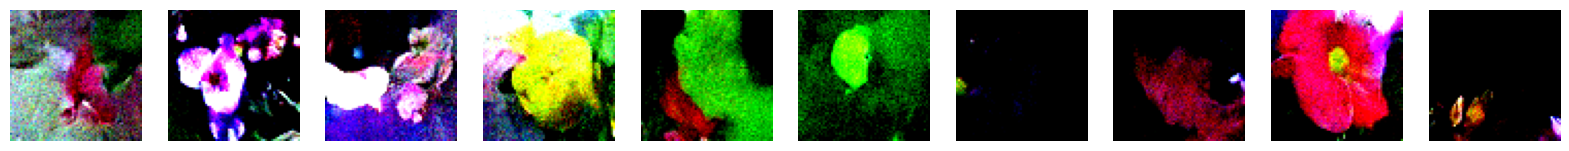

In [45]:
generated_images = ddm.generate(num_images=20, diffusion_steps=300).numpy()
display(generated_images)

### Test Different Step Counts
Compare generation quality with varying numbers of diffusion steps (1 to 300).

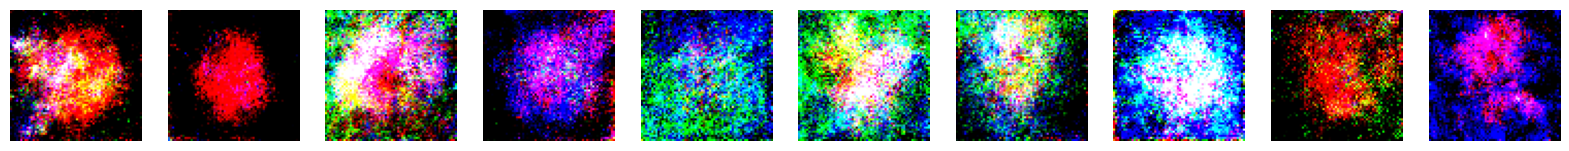

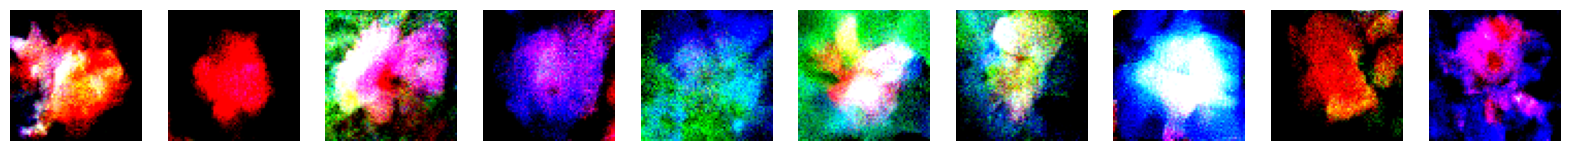

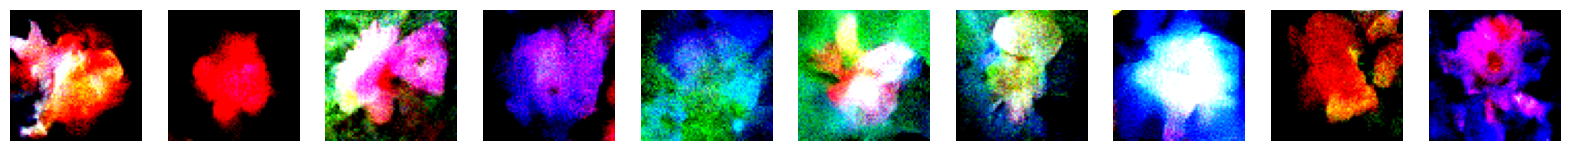

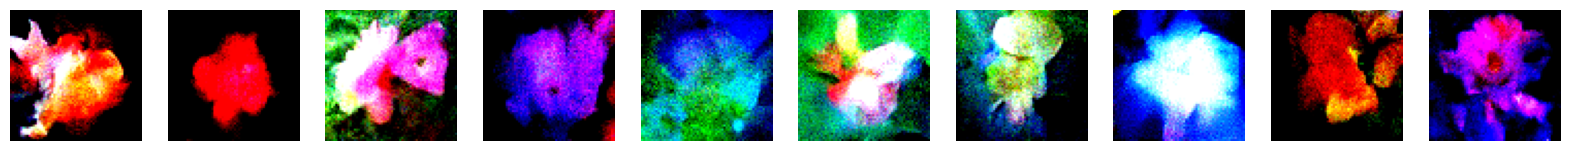

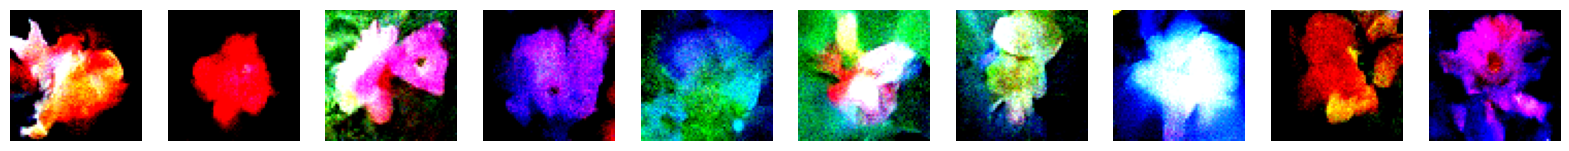

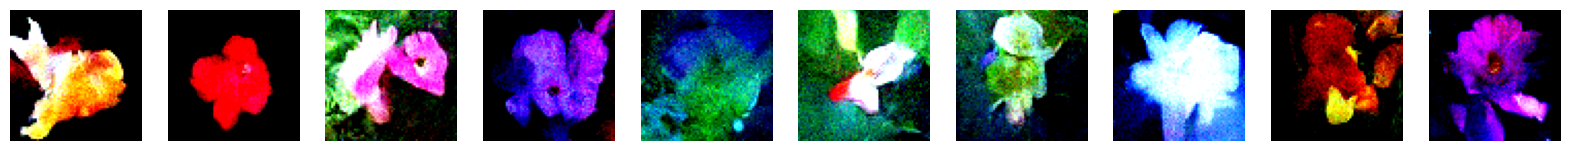

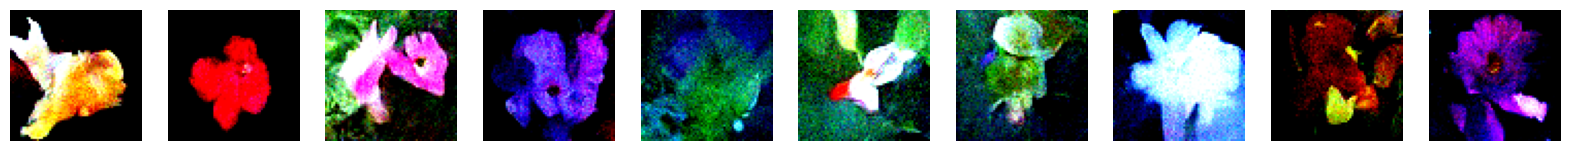

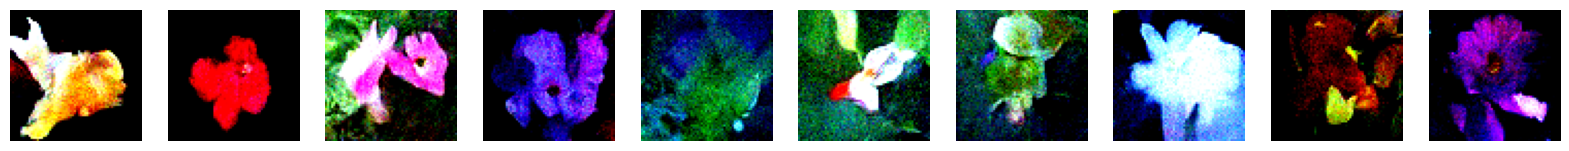

In [46]:
for diffusion_steps in list(np.arange(1, 6, 1)) + [20, 100, 300]:
    tf.random.set_seed(42)
    generated_images = ddm.generate(
        num_images=10,
        diffusion_steps=diffusion_steps,
    ).numpy()
    display(generated_images)


### Latent Space Interpolation
Generate smooth transitions between different flower images by interpolating in noise space.

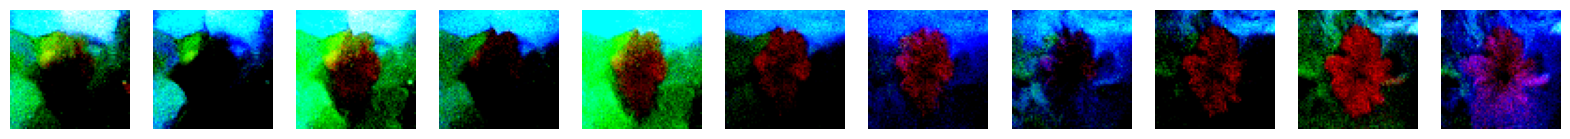

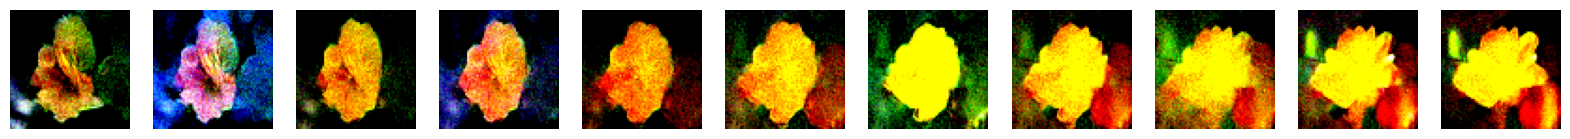

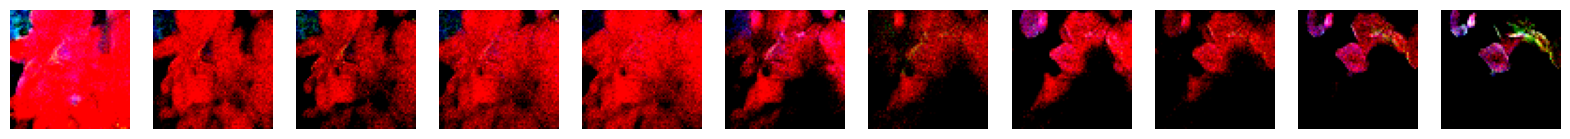

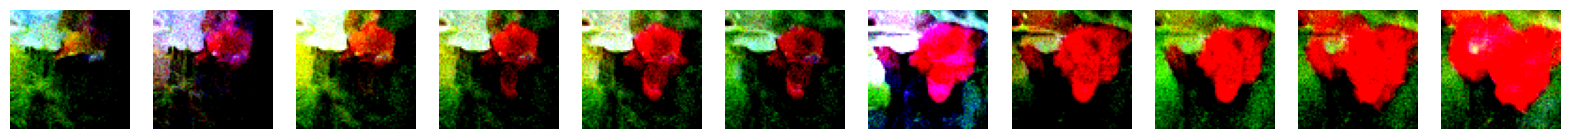

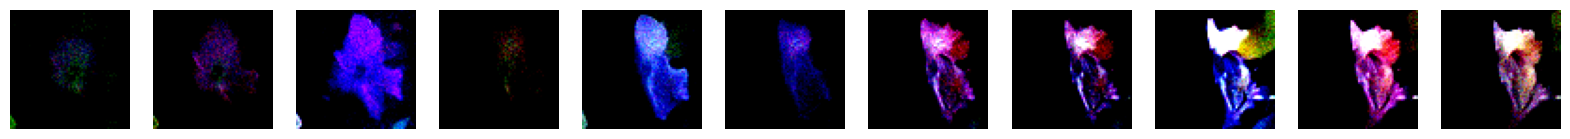

In [43]:
tf.random.set_seed(150)

def spherical_interpolation(a, b, t):
    t = tf.cast(t, tf.float32)
    return tf.sin(t * math.pi / 2) * a + tf.cos(t * math.pi / 2) * b

for i in range(5):
    a = tf.random.normal(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    b = tf.random.normal(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    initial_noise = tf.stack(
        [spherical_interpolation(a, b, t) for t in np.arange(0, 1.1, 0.1)]
    )

    generated_images = ddm.generate(
        num_images=11, diffusion_steps=20, initial_noise=initial_noise
    ).numpy()

    display(generated_images, n=11)


Generating flowers from 10 different classes
Each image should look DIFFERENT (different flower species)



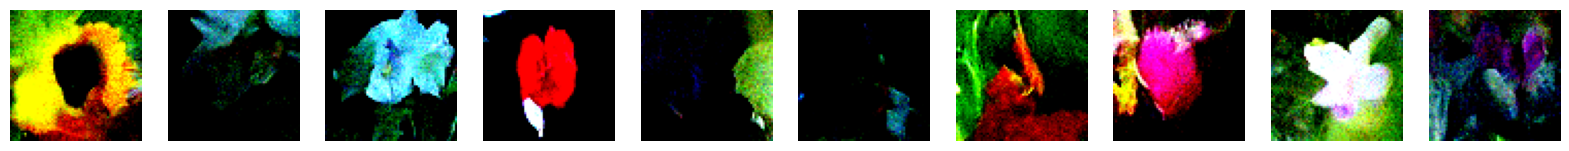


Class IDs (left to right): [ 0 10 20 30 40 50 60 70 80 90]


In [47]:
# Generate diverse classes side by side
print("Generating flowers from 10 different classes")
print("Each image should look DIFFERENT (different flower species)\n")

# Select 10 evenly spaced classes
diverse_classes = tf.constant([i * 10 for i in range(10)], dtype=tf.int32)
diverse_flowers = ddm.generate(
    num_images=10,
    diffusion_steps=100,
    class_labels=diverse_classes
).numpy()

display(diverse_flowers)

# Show which class each image represents
print("\nClass IDs (left to right):", diverse_classes.numpy())

Testing Class-Conditional Generation
Each row should show flowers from the SAME class
If conditioning works, flowers in each row should look similar


Class 0:


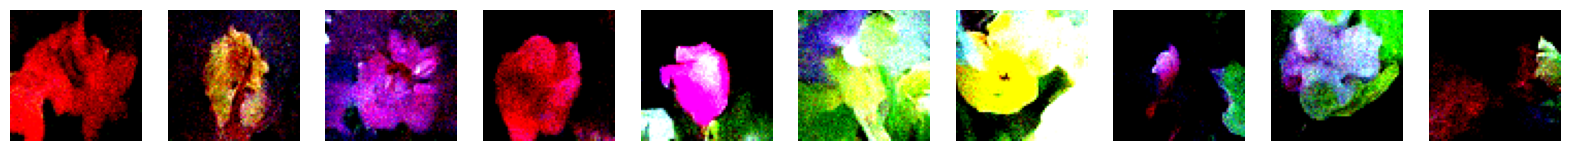


Class 10:


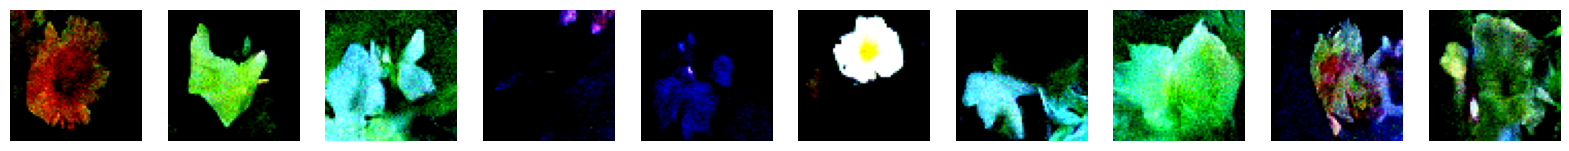


Class 25:


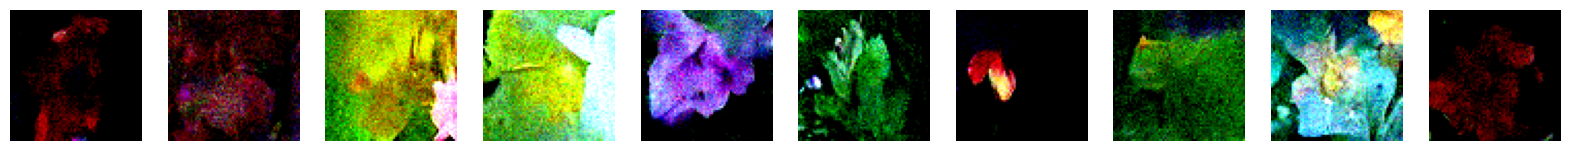


Class 50:


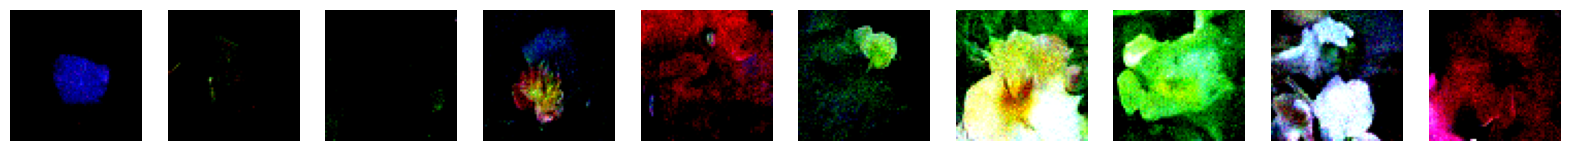


Class 75:


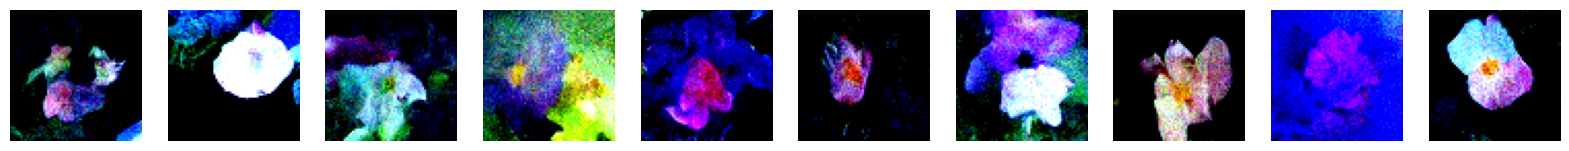


Class 101:


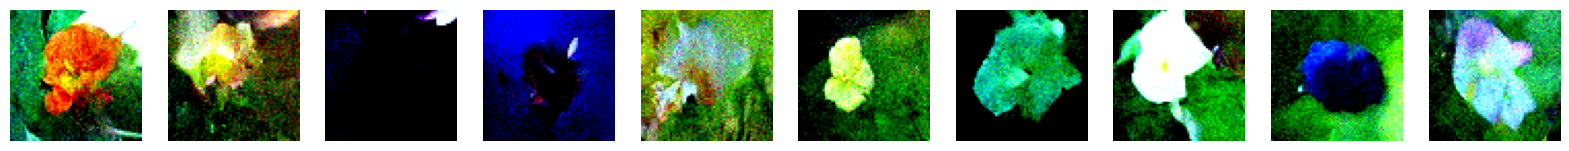

In [48]:
# Test class-conditional generation
# Generate flowers from specific classes
test_classes = [0, 10, 25, 50, 75, 101]  # Sample across the 102 classes

print("Testing Class-Conditional Generation")
print("="*60)
print("Each row should show flowers from the SAME class")
print("If conditioning works, flowers in each row should look similar\n")

for class_id in test_classes:
    print(f"\nClass {class_id}:")
    # Generate 10 images all from the same class
    class_labels = tf.constant([class_id] * 10, dtype=tf.int32)
    generated_images = ddm.generate(
        num_images=10, 
        diffusion_steps=100,
        class_labels=class_labels
    ).numpy()
    display(generated_images)